In [36]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# この1行を追加するだけで、全軍のグラフに日本語フォントが適用される
import japanize_matplotlib

In [37]:
data_dir = "playground-series-s6e3"

train = pd.read_csv(os.path.join(data_dir, "train.csv"))
test = pd.read_csv(os.path.join(data_dir, "test.csv"))
sample_sub = pd.read_csv(os.path.join(data_dir, "sample_submission.csv"))

In [38]:
print(train.shape)
print(test.shape)

(594194, 21)
(254655, 20)


In [39]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [40]:
test.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [41]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  str    
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  str    
 4   Dependents        594194 non-null  str    
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  str    
 7   MultipleLines     594194 non-null  str    
 8   InternetService   594194 non-null  str    
 9   OnlineSecurity    594194 non-null  str    
 10  OnlineBackup      594194 non-null  str    
 11  DeviceProtection  594194 non-null  str    
 12  TechSupport       594194 non-null  str    
 13  StreamingTV       594194 non-null  str    
 14  StreamingMovies   594194 non-null  str    
 15  Contract          594194 non-null  str    
 16  PaperlessBilling  594194 non-nu

In [42]:
train.dtypes

id                    int64
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [51]:
train.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000
mean,0.114102,36.577258,65.866223,2494.377057
std,0.317936,25.061922,31.067444,2353.916710
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,12.000000,29.900000,639.650000
50%,0.000000,35.000000,74.100000,1433.650000
75%,0.000000,62.000000,90.800000,4263.800000
max,1.000000,72.000000,118.750000,8684.800000


In [53]:
train.describe(include="str").T

,count,unique,top,freq
gender,594194,2,Female,298738
Partner,594194,2,Yes,309554
Dependents,594194,2,No,414362
PhoneService,594194,2,Yes,557893
MultipleLines,594194,3,No,283384
InternetService,594194,3,Fiber optic,272386
OnlineSecurity,594194,3,No,289474
OnlineBackup,594194,3,No,250083
DeviceProtection,594194,3,No,247377
TechSupport,594194,3,No,288571


Churn（離反・解約）: 今回の戦における唯一の標的（目的変数）である。通信やサブスクリプション業界において、顧客がサービスに見切りをつけて「解約して去っていく」行動を指す。

tenure（契約期間）: 原義は「保有」や「在任期間」を示すが、このビジネス領域においては、顧客がサービスを継続利用している「契約期間（通常は月数）」を意味する。一般的に、契約期間が長い顧客ほど離反（Churn）しにくい傾向があり、予測において極めて強い影響力を持つ中核的な変数となる。

Dependents（扶養家族）: 原義は「依存している人」であり、転じて「扶養家族（子供や高齢の親など）」を意味する。配偶者を示す Partner 列と併せることで、その顧客が単身者なのか、家族持ちなのかという世帯構成を類推できる。

PaperlessBilling（ペーパーレス請求）: 請求書（Billing）を紙媒体ではなく、電子データとして受け取っているか否かを示す。ITリテラシーや支払いに対する意識を測る指標となり得る。

MultipleLines / TechSupport / OnlineSecurity: それぞれ「複数回線」「技術サポート」「オンラインセキュリティ」を示す。これら付加価値サービス（オプション）への加入状況は、顧客のサービスへの依存度（ロックイン効果）を測るための重要な要素である。

In [57]:
# カテゴリカル変数に変換

# 変換前のメモリ使用量（深いレベルで正確に計測）
mem_before = train.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"【変換前】全軍のメモリ消費量: {mem_before:.2f} MB")

# ユニーク数が10以下のobject（文字列）列を抽出し、一括でcategory型へ変換
object_cols = [col for col in train.columns if train[col].dtype == 'str' or train[col].nunique() <= 10]

for col in object_cols:
    train[col] = train[col].astype('category')

# 変換後のメモリ使用量
mem_after = train.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"【変換後】全軍のメモリ消費量: {mem_after:.2f} MB")
print(f"▶ 削減効果: 約 {(1 - mem_after/mem_before)*100:.1f} % のメモリを節約した。")

【変換前】全軍のメモリ消費量: 27.20 MB
【変換後】全軍のメモリ消費量: 23.24 MB
▶ 削減効果: 約 14.6 % のメモリを節約した。


In [58]:
train.dtypes

gender              category
SeniorCitizen       category
Partner             category
Dependents          category
tenure                 int64
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float64
TotalCharges         float64
Churn               category
dtype: object

In [48]:
# Idはノイズなので不要
train = train.drop(["id"], axis=1)

--- 数値変数の外れ値索敵 ---


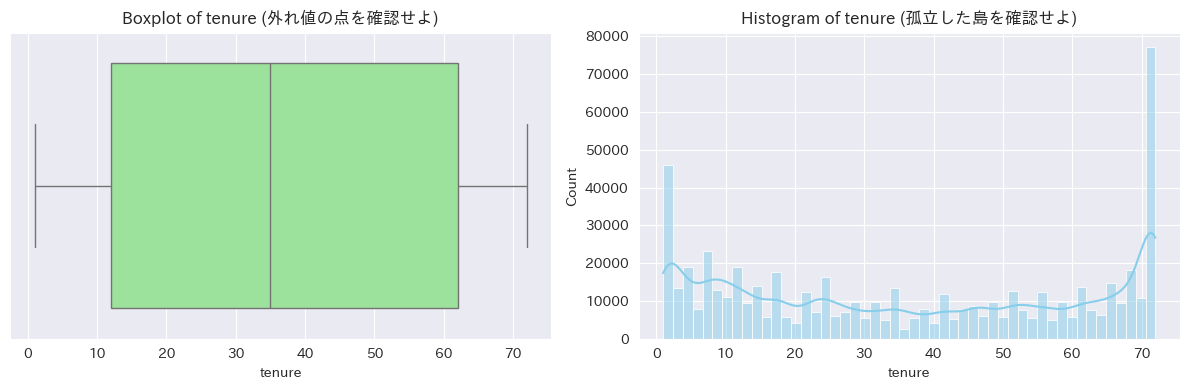

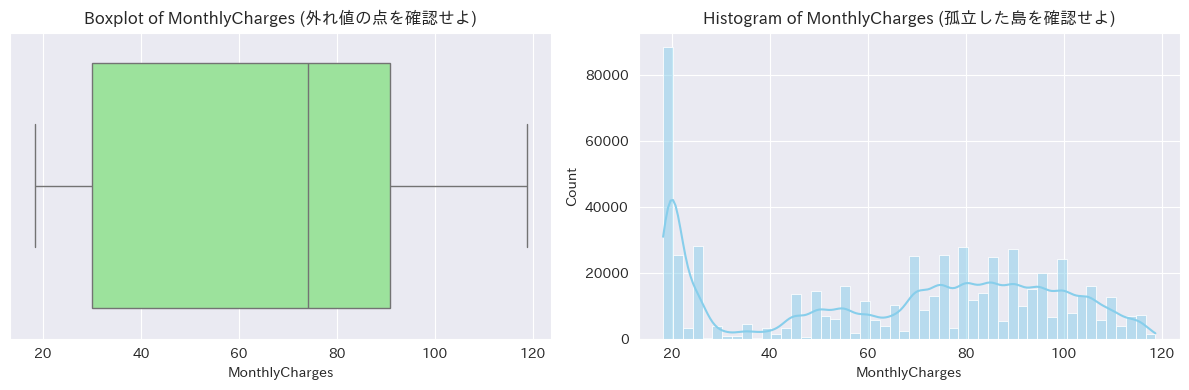

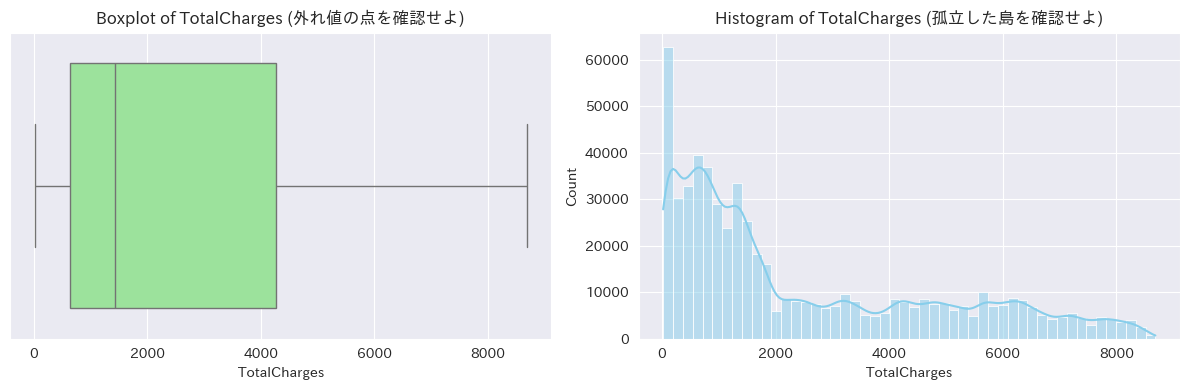

In [59]:
# 数値変数のみを抽出
numeric_cols = train.select_dtypes(include=['number'])

print("--- 数値変数の外れ値索敵 ---")

for col in numeric_cols:
    # 1つの変数につき、横に2つのキャンバス（1行2列）を用意する
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 左の眼：単変量の箱ひげ図（Boxplot）
    # orient='h'で横向きに描き、外れ値の点を視認しやすくする
    sns.boxplot(data=train, x=col, ax=axes[0], color='lightgreen')
    axes[0].set_title(f'Boxplot of {col} (外れ値の点を確認せよ)')

    # 右の眼：高解像度のヒストグラム（Histogram）
    # bins=50と細かく刻み、孤立したデータがないか探る
    sns.histplot(data=train, x=col, bins=50, kde=True, ax=axes[1], color='skyblue')
    axes[1].set_title(f'Histogram of {col} (孤立した島を確認せよ)')

    plt.tight_layout()
    plt.show()

--- 数値変数 vs 離反の分布 ---


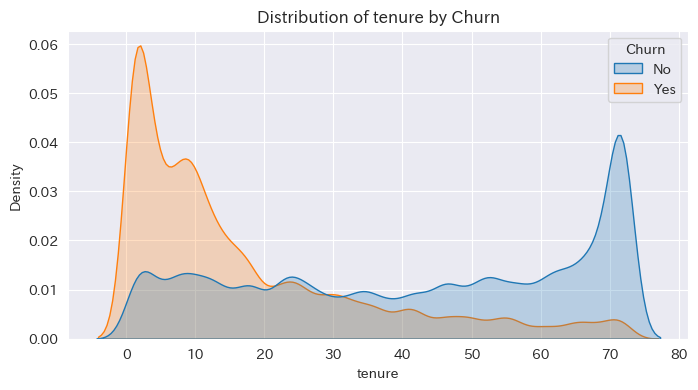

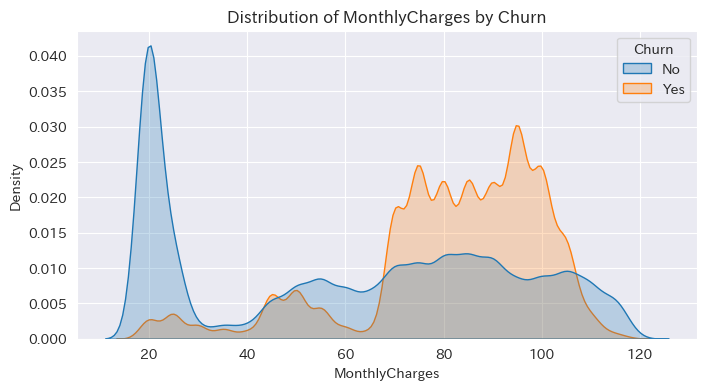

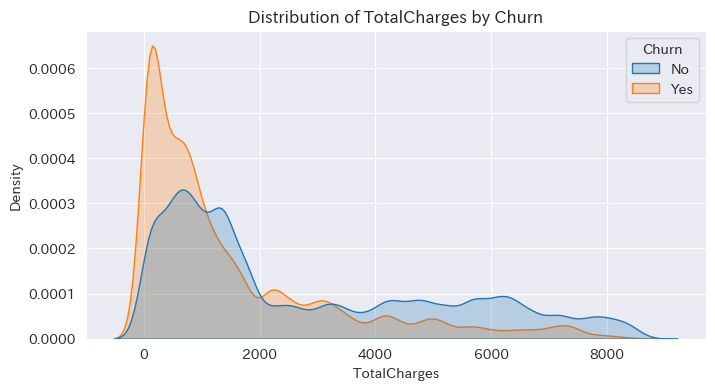

In [60]:
# 数値変数と離反（Churn）の関係を視覚化
numeric_cols = train.select_dtypes(include=['number'])

print("--- 数値変数 vs 離反の分布 ---")
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    # KDE（カーネル密度推定）を用いて、離反者と継続者の分布のズレを可視化する
    sns.kdeplot(data=train, x=col, hue='Churn', fill=True, common_norm=False)
    plt.title(f'Distribution of {col} by Churn')
    plt.show()

tenure（契約期間）が長い人は離反しづらいが、70弱になると急激に離反しない密度が跳ね上がる。
Monthly Chargesが10～30ほどの顧客は離反非常にしづらい。電話やインターネット等のサービスを利用しない人たちだろう。
TotalChargesは当然低い方が離反しやすいが、tenureと見比べると密度の差は小さい。
Monthly Chargesが低い人ほど契約期間が長いことを示しているか。

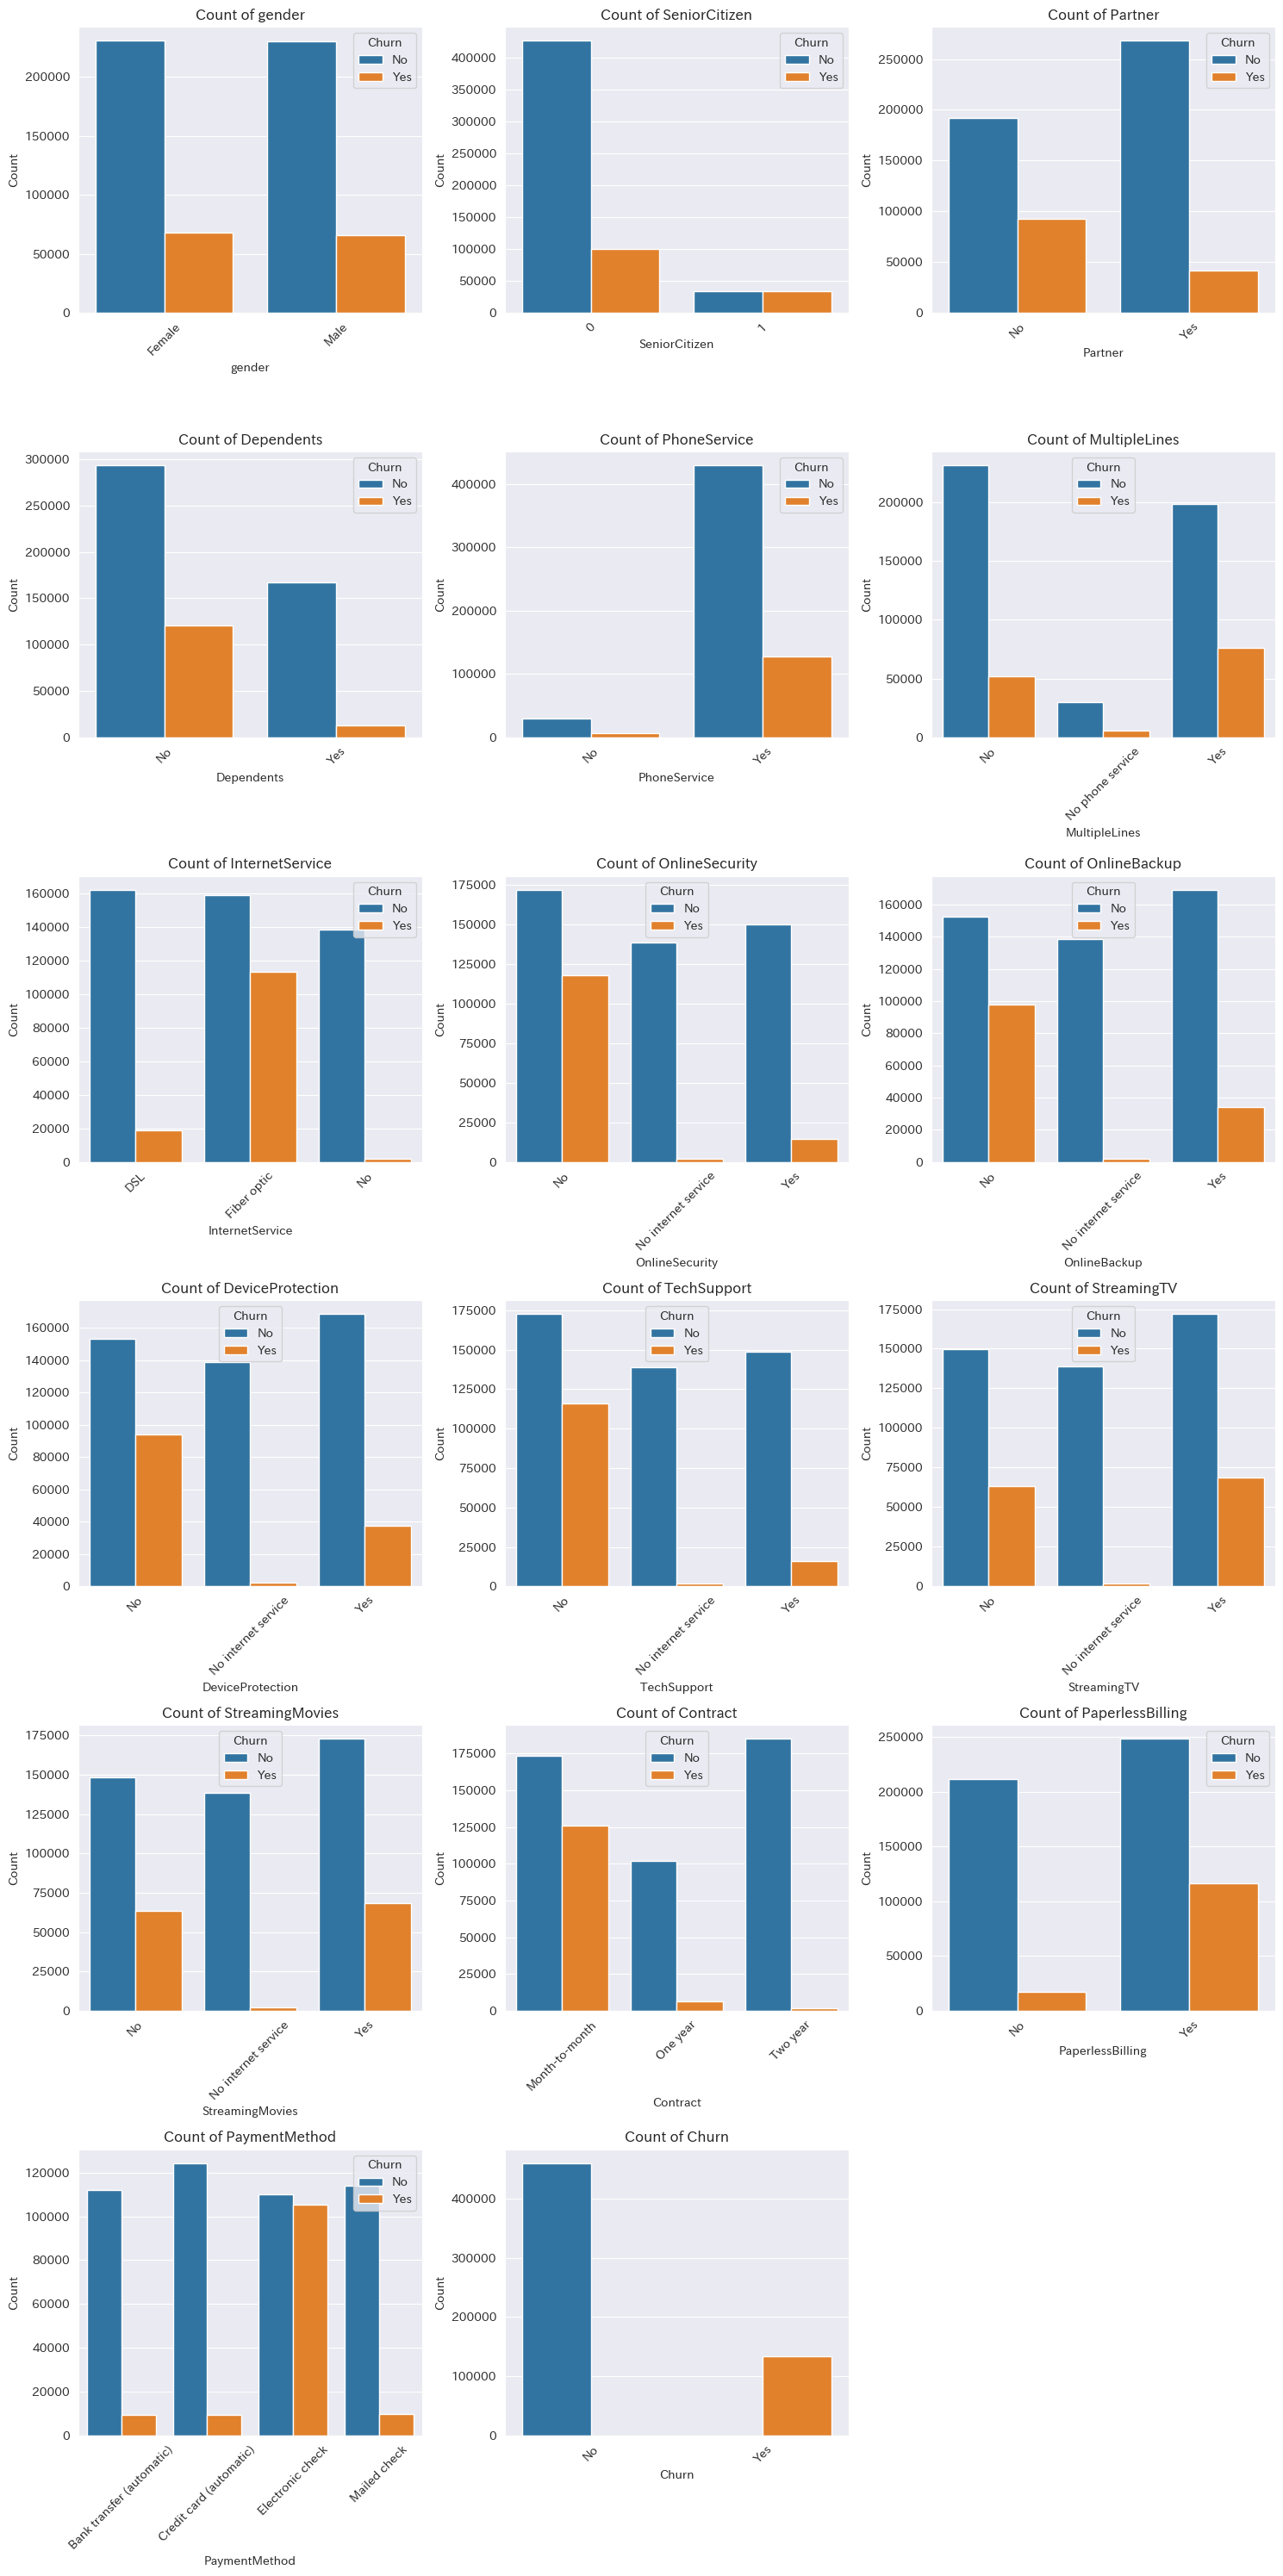

In [64]:
# 種類が10以下のカテゴリ変数を抽出
# ただし、目的変数（Churn, Churn_Num）や不要なidは除外する
target_cols = [col for col in train.columns if train[col].dtype == 'category']

# グラフを配置するグリッドの計算（横に3つずつ並べる陣形）
n_cols = 3
n_rows = (len(target_cols) + n_cols - 1) // n_cols

# 広域魔法の展開：巨大なキャンバスを用意する
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() # 2次元配列を1次元に平坦化して扱いやすくする

for i, col in enumerate(target_cols):
    # 各マス（ax）にcountplotを展開
    sns.countplot(data=train, x=col, hue='Churn', ax=axes[i])
    axes[i].set_title(f'Count of {col}', fontsize=12)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45) # ラベルを見やすく傾ける

# 余った空白のマス（キャンバス）を削除して陣形を整える
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

ChurnがNoの顧客が多いゆえほとんどがグラフがChurnが方に大きい傾向にある。しかし、SeniorCitizenが1、InternetServiceがFiber optic、OnlineSecurityとOnlineBackUpとDeviceProtectionとTechSupportがNo、ContractがMonth-to-month、PaymentMethodがElectronic checkだとChurnがYesが大きくなっている。ここからわかるのは、ネット環境のない顧客は離反しにくく、ネット環境があってもサービスに加入しない顧客は離反しやすいということ。今度は光ファイバーを使っているユーザーがサービスに契約している分布を見る必要があるか。

In [65]:
# 偵察対象の選定：ユニークな値の数が一定以下（例：20以下）、または文字列/カテゴリ型の列のみを抽出
target_cols = [col for col in train.columns if train[col].dtype in ['category']]

print(f"全{train.shape[1]}列中、偵察対象となったのは {len(target_cols)} 列である。\n")

for col in target_cols:
    print(f"=== 陣容: {col} ===")
    # 欠損値があればそれも集計対象に含める(dropna=False)
    # 割合(normalize=True)も併記し、偏りを客観的数値で把握する
    counts = train[col].value_counts(dropna=False)
    ratios = train[col].value_counts(dropna=False, normalize=True) * 100

    # 視認性を高めるため、データフレームとして結合して表示
    summary_df = pd.DataFrame({'Count': counts, 'Ratio (%)': ratios})
    display(summary_df)
    print("\n")

全20列中、偵察対象となったのは 17 列である。

=== 陣容: gender ===


,Count,Ratio (%)
gender,,
Female,298738,50.276172
Male,295456,49.723828




=== 陣容: SeniorCitizen ===


,Count,Ratio (%)
SeniorCitizen,,
0,526395,88.589754
1,67799,11.410246




=== 陣容: Partner ===


...

,Count,Ratio (%)
PaperlessBilling,,
Yes,365579,61.525192
No,228615,38.474808




=== 陣容: PaymentMethod ===


,Count,Ratio (%)
PaymentMethod,,
Electronic check,215372,36.246075
Credit card (automatic),133705,22.501910
Mailed check,123757,20.827709
Bank transfer (automatic),121360,20.424306




=== 陣容: Churn ===


,Count,Ratio (%)
Churn,,
No,460377,77.479241
Yes,133817,22.520759


In [ ]:
train["Churn_num"] = train["Churn"].map({"Yes": 1, "No": 0})
X_train = train.drop(["id", "Churn"], axis=1)

In [ ]:
test_ids = test["id"]
X_test = test.drop("id", axis=1)